02 - Construct a zero-coupon (spot) yield curve from Treasury market quotes by bootstrapping discount factors recursively.

• Discount factors for every maturity

• Zero (spot) rates

• A complete zero-coupon yield curve

• Comparison of par yields vs. spot rates

• A reusable bootstrap implementation

Understand:

• Why par yields cannot be used directly for pricing cash flows

• The relationship between discount factors and spot rates

• Recursive bootstrapping

• The difference between par curves and zero curves

Explain:

- Par yield curve

- Spot (zero) yield curve

- Discount factors

- Why bond pricing requires spot rates instead of par yields

Illustrate the workflow:

Market Quotes -> Bootstrapping -> Discount Factors -> Spot Rates -> Zero Curve

In [126]:
from pathlib import Path
ROOT = Path.cwd().parent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [127]:
curve = pd.read_csv(ROOT / "data/clean_treasury_curve.csv")

bills = curve[curve["Years"] <= 1].copy() # Bills have maturity <= 1Y

notes = curve[curve["Years"] > 1].copy() # Notes have maturity > 1Y

price = 100 # Assumed

display(bills)

display(notes)

,Maturity,Yield,Years,Discount Factor
0,3M,3.89,0.25,0.990505
1,6M,4.03,0.50,0.980439
2,1Y,4.12,1.00,0.960430


,Maturity,Yield,Years,Discount Factor
3,2Y,4.26,2.0,0.919951
4,3Y,4.30,3.0,0.881347
5,5Y,4.37,5.0,0.807461
6,7Y,4.48,7.0,0.735814
7,10Y,4.62,10.0,0.636580
8,20Y,5.11,20.0,0.369079
9,30Y,5.10,30.0,0.224863


In [128]:
# Zeros
bootstrap = {}
for _, row in bills.iterrows():
    bootstrap[row["Years"]] = row["Discount Factor"]




In [129]:
# Interpolate discount factors for semi-annual payments
import numpy as np
from scipy.interpolate import CubicSpline

cs = CubicSpline(curve["Years"], curve["Yield"])
grid = np.arange(0.5, 30.5, 0.5)
interp = pd.DataFrame({"Years": grid, "Yield": cs(grid)})



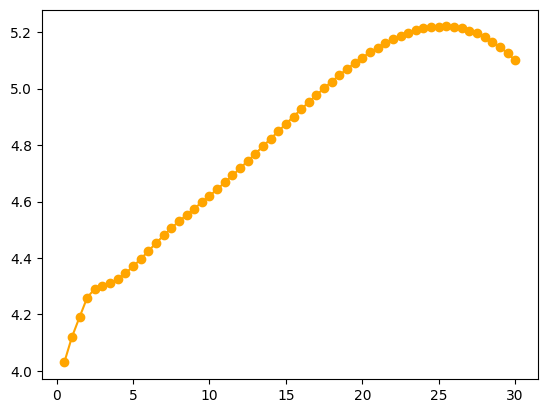

In [130]:
plt.plot(interp["Years"], interp["Yield"], marker='o', color='orange')

In [131]:
bootstrap

{0.25: 0.9905047520044288, 0.5: 0.980439276376235, 1.0: 0.9604302727621976}

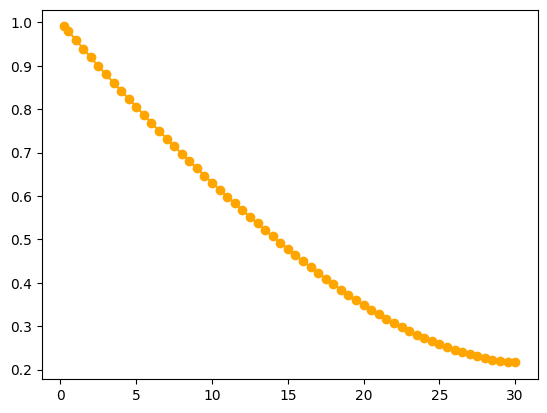

In [132]:
# Bootstrap notes
for _, row in interp.iterrows():
    T = row["Years"]

    if T <= 1:
        continue

    coupon = row["Yield"] * price / 100 / 2 # Semi-annual coupon

    coupon_dates = np.arange(0.5, T, 0.5) # Semi-annual coupon dates

    pv = 0

    for t in coupon_dates:
        pv += coupon * bootstrap[t]

    df = (price - pv) / (price + coupon) # Solve for discount factor 

    bootstrap[T] = df

plt.plot(bootstrap.keys(), bootstrap.values(), marker='o', color='orange')

In [133]:
zero_curve = pd.DataFrame(bootstrap.items(), columns = ["Years", "Discount Factor"])
zero_curve

,Years,Discount Factor
0,0.25,0.990505
1,0.50,0.980439
2,1.00,0.960430
3,1.50,0.939646
4,2.00,0.919069
...,...,...
56,28.00,0.226335
57,28.50,0.222953
58,29.00,0.220138
59,29.50,0.217902


In [134]:
# Rearrange for spot rates
zero_curve["Spot Rate"] = 100 * (zero_curve["Discount Factor"] ** (-1 / zero_curve["Years"]) - 1)
zero_curve

,Years,Discount Factor,Spot Rate
0,0.25,0.990505,3.890000
1,0.50,0.980439,4.030000
2,1.00,0.960430,4.120000
3,1.50,0.939646,4.237461
4,2.00,0.919069,4.310007
...,...,...,...
56,28.00,0.226335,5.449517
57,28.50,0.222953,5.407068
58,29.00,0.220138,5.357552
59,29.50,0.217902,5.300835


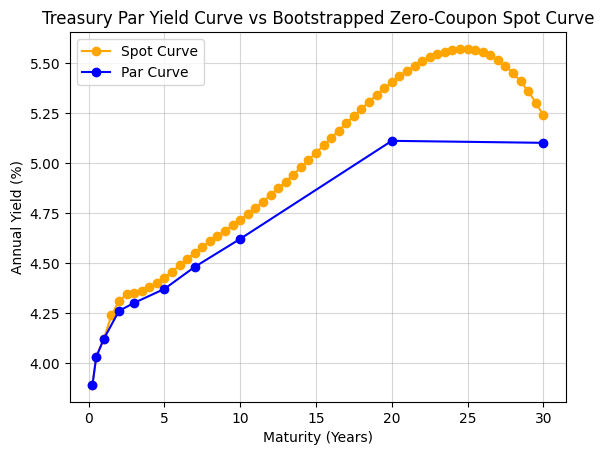

In [135]:
plt.plot(zero_curve["Years"], zero_curve["Spot Rate"], marker='o', color='orange', label = "Spot Curve")
plt.plot(curve["Years"], curve["Yield"], marker='o', color='blue', label = "Par Curve")

plt.xlabel("Maturity (Years)")
plt.ylabel("Annual Yield (%)")
plt.title("Treasury Par Yield Curve vs Bootstrapped Zero-Coupon Spot Curve")

plt.legend()
plt.grid(alpha = 0.5)

In [136]:
zero_curve.to_csv(ROOT / "data/zero_curve.csv")

In [137]:
# Validation - reprice bonds, they should work out to ~$100
def price_bond(face, coupon_rate, maturity, discount_curve, frequency=2):
    """
    Prices a coupon bond using bootstrapped discount factors.

    Parameters
    ----------
    face : float
        Face value (typically 100)
    coupon_rate : float
        Annual coupon rate in percent (e.g. 4.25)
    maturity : float
        Maturity in years
    discount_curve : dict
        Dictionary of discount factors keyed by maturity
    frequency : int
        Coupon payments per year

    Returns
    -------
    float
        Model price
    """

    coupon = face * coupon_rate / 100 / frequency

    payment_dates = np.arange(
        1/frequency,
        maturity + 1e-9,
        1/frequency
    )

    price = 0

    for t in payment_dates[:-1]:
        price += coupon * discount_curve[t]

    price += (face + coupon) * discount_curve[maturity]

    return price

prices = []

for _, row in interp.iterrows():

    if row["Years"] <= 1:
        continue

    price = price_bond(
        face=100,
        coupon_rate=row["Yield"],
        maturity=row["Years"],
        discount_curve=bootstrap
    )

    prices.append({
        "Years": row["Years"],
        "Coupon": row["Yield"],
        "Model Price": price
    })

validation = pd.DataFrame(prices)

validation

,Years,Coupon,Model Price
0,1.5,4.190501,100.0
1,2.0,4.260000,100.0
2,2.5,4.291258,100.0
3,3.0,4.300000,100.0
4,3.5,4.310204,100.0
5,4.0,4.325905,100.0
6,4.5,4.346154,100.0
7,5.0,4.370000,100.0
8,5.5,4.396456,100.0
9,6.0,4.424388,100.0
